## 🎯 **Problem Formulation (Định nghĩa mục tiêu)**

**Mục tiêu:** Mục tiêu của bài toán là xây dựng mô hình phân loại nhàm dự đoán khả năng rời bỏ của một khách hàng thông qua hợp đồng sử dụng, giá hợp đồng theo tháng, thời gian mà khách hàng đó trải nghiệm dịch vụ.

**Mục tiêu dự đoán:** Xác định các yếu tố ảnh hưởng mạnh đến khả năng rời bỏ của khách hàng, giảm chi phí để giữ chân hoặc loại bỏ một khách hàng

**Các mô hình được sử dụng:**
- Logistic Regression
- Random Forest
- XGBoost

**Lý do lựa chọn mô hình được giải thích như sau:**
- Logistic Regression: Muốn chọn làm mô hình baseline giúp căn chỉnh ngưỡng sao cho tối ưu khả năng dự đoán rời bỏ cũng như suy nghĩ đến việc dự đoán khách hàng rời bỏ hoặc chấp nhận dự đoán sai khách hàng
- Random Forest: Xem các đặc trưng nào có yếu tố ảnh hưởng nhiều đến với tỷ lệ rời bỏ của một khách hàng
- XGBoost: Nâng cao hơn Random Forest giúp nhận ra nhiều yếu tố ảnh hưởng mà Random Forest không thể nhìn thấy

Mô hình được đánh giá dựa theo cac chỉ số **Precision, Recall, F1-Score, Accuracy** trong đó ưu tiên **Recall** vì giúp phát hiện dự đoán rời bỏ nhiều hơn

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [118]:
telco = pd.read_csv('telco_customer.csv')
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## ⏫ **Data Prepocessing (Chuẩn bị dữ liệu)**

In [119]:
telco.info() # Kiểm tra kiểu dữ liệu từng đặc trưng

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [120]:
telco['SeniorCitizen'] = telco['SeniorCitizen'].astype('object')

## 🔀 **Train – Validation – Test Split (Chia tập huấn luyện và đánh giá)**

In [121]:
telco.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [122]:
drop_columns = ['gender', 'customerID', 'TotalCharges', 'Churn']

target = telco['Churn']
features = telco.drop(drop_columns, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

X_train.shape, X_test.shape

((5634, 17), (1409, 17))

In [123]:
num_freatures = features.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = features.select_dtypes(include=['object']).columns.tolist()

print("Num features: ", num_freatures)
print("Cat features: ", cat_features)

Num features:  ['tenure', 'MonthlyCharges']
Cat features:  ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [124]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # Không sinh thứ tự giả, an toàn
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_freatures),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

## 🤖 **Model Selection (Lựa chọn mô hình)**

In [128]:
logistic_regression = LogisticRegression(max_iter=1000, class_weight='balanced') # Thêm balancef để phạt nặng hơn khi dự đoán sai rời bỏ, nhằm tăng recall giảm acc

pipe_logistic_regression = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("classifier", logistic_regression)
])

## 🏋️**Model Training (Huấn luyện mô hình)**

In [129]:
pipe_logistic_regression.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## 📊 **Model Evaluation (Đánh giá mô hình)**

In [135]:
y_test = y_test.map({'No': 0, 'Yes': 1})

              precision    recall  f1-score   support

           0       0.93      0.65      0.76      1035
           1       0.47      0.86      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.80      0.70      0.72      1409



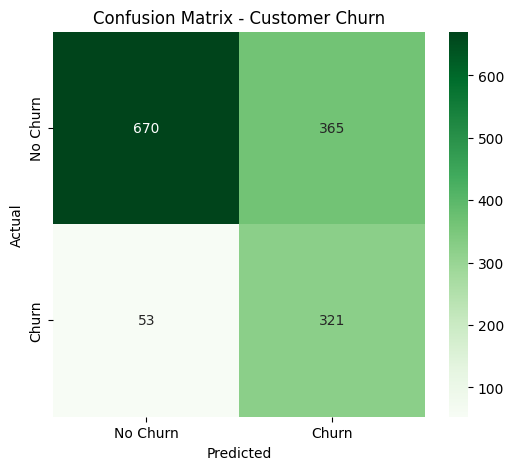

In [136]:
y_pred_logistic_regression = pipe_logistic_regression.predict(X_test)
y_proba_logistic_regression = pipe_logistic_regression.predict_proba(X_test)[:, 1]

threshold = 0.4
y_pred_logistic_regression_new = (y_proba_logistic_regression >= threshold).astype(int)

print(classification_report(y_test, y_pred_logistic_regression_new))

cm = confusion_matrix(y_test, y_pred_logistic_regression_new)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Customer Churn")
plt.show()

**Nhận xét**

- Chỉ số (Accuracy): **0.8** nhưng Recall: **0.56** thể hiện mô hình chỉ bắt được 56% khách hàng rời bỏ, 44% còn lại bị bỏ sót

Tức mô hình đang  dự đoán khá tốt nhóm không rời bỏ, nhưng lại bó sót khá nhiều nhóm rời bỏ

Nếu mục tiêu là giảm mất khách thì dây không phải là một mô hình tốt

- Sau khi tăng nặng việc phạt thì Recall tăng cho tháy mô hình bắt được 78& khách hàng rời bỏ, nhưng lại dự đoán nhiều khách hàng không trung thành hơn

- Tiếp tục tăng threshold giúp cho mô hình tăng dự đoán nhiều rời bỏ hơn nhừng đoán nhầm người  không churn là churn lại nhiều hơn

> Nếu đây là bài toán giảm chi phí doanh nghiệp thì mô hình tương đối tốt

## 🏆 **Model Comparison (So sánh mô hình)**

## ⚙️ **Hyperparameter Tuning (Tổi ưu hóa tham số)**

## 🔎 **Feature Importance (Đặc trưng quan trọng)**

## 📝 **Conclusion (Kết luận)**